# Sentinel-1 SAR Backscatter -- VH / VV / VH:VV RGB Composite

This notebook is an end-to-end **manual** validation of the `sar_backscatter` process
(ADR [`docs/adr/0001-sar-backscatter.md`](../adr/0001-sar-backscatter.md), Phase 1:
ellipsoid coefficients only). It loads Sentinel-1 GRD `vv`/`vh`, calibrates both
polarisations to `sigma0-ellipsoid`, and assembles the classic dual-pol SAR
false-colour composite used to sanity-check a backscatter product by eye:

| Channel | Source | What it emphasises |
| --- | --- | --- |
| **Red** | VH (cross-pol) | Volume scattering -- vegetation, forest canopy |
| **Green** | VH / VV (as dB difference: VH(dB) - VV(dB)) | Scattering-mechanism contrast -- vegetation vs. bare/smooth surfaces |
| **Blue** | VV (co-pol) | Surface / double-bounce scattering -- water (dark), urban structures (bright) |

There is no ground truth check here -- this is a *plausibility* validation (does the
scene look like a real Sentinel-1 composite: water dark, vegetation reddish, urban
bright), the same spirit as the ADR's own acceptance criterion 1 (S7.8), just visual
instead of a single dB number.

**Requires:** a running local titiler-openeo backend configured against a real STAC
catalogue with credentials (see `.env.cdse`), and the `openeo` Python client
(`pip install openeo`) -- these notebooks run in their own environment, `openeo` is not
a project dependency.

## Import Required Libraries

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import openeo

## Connect to OpenEO Backend

Connect to a local OpenEO backend running on port 8081 and authenticate using OpenID
Connect (same pattern as the other notebooks in this folder).

In [10]:
# connection = openeo.connect(
#     url="https://openeo.ds.io"
# ).authenticate_oidc_authorization_code()

connection = openeo.connect(
    url="http://127.0.0.1:8082/"
).authenticate_oidc_authorization_code()

## Load Sentinel-1 GRD

The AOI below covers the Rotterdam port area: open water in the port basins, dense
urban/industrial structures, and farmland just inland -- enough land-cover variety to
exercise all three composite channels in a single scene.

**Adjust `spatial_extent`/`temporal_extent` to a date you know has real coverage** --
pick a window narrow enough to contain a single Sentinel-1 acquisition over the AOI;
this notebook assumes exactly that (see the `mean_time()` step below).

**One item per acquisition datetime.** `load_collection` groups items by acquisition
datetime and mosaics each group into a single image. Calibration is inherently
per-item -- every product carries its own calibration/noise LUTs and its own
geolocation grid -- so `sar_backscatter` refuses a slice that mosaics several items
rather than applying one item's radiometry to another's pixels. In practice each
Sentinel-1 slice has a distinct start time, so this is rarely hit; if you do see
that error, narrow the extent until each datetime resolves to one item.

In [11]:
spatial_extent = {"west": 4.20, "south": 51.85, "east": 4.55, "north": 51.98}
temporal_extent = ["2026-06-01", "2026-06-10"]  # adjust to a real S1 pass over the AOI

s1 = connection.load_collection(
    "sentinel-1-grd",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["vv", "vh"],
)

## Calibrate to Backscatter

`sar_backscatter` isn't one of the openEO client's built-in convenience methods (it's
not a core process), so it's called generically via `.process()`. `coefficient=
"sigma0-ellipsoid"` and `noise_removal=True` are within Phase 1's supported set --
`gamma0-terrain`, the openEO spec's own default, is deliberately rejected by this
back-end (see the ADR). `mask=True` adds a `mask` band (1.0 valid, 0.0 border/no-data)
so the composite below can black out the scene's own padding instead of plotting noise
there.

In [12]:
backscatter = s1.process(
    "sar_backscatter",
    data=s1,
    coefficient="sigma0-ellipsoid",
    noise_removal=True,
    mask=True,
)

# Collapse the temporal dimension -- a no-op if temporal_extent above matched exactly
# one acquisition, which is what this notebook assumes.
backscatter = backscatter.reduce_dimension(dimension="t", reducer="first")

backscatter.download("sar_backscatter_vv_vh_mask.tif", format="GTiff")

## Build the VH / VV / VH:VV Composite

Bands come out in the order `sar_backscatter` documents: the requested polarisations
first (`vv`, `vh`, matching `bands=` above), then `mask` (`ellipsoid_incidence_angle`
wasn't requested, so it's absent). The calibrated values are still **linear power** --
SAR composites are conventionally built in decibels, which turns the VH/VV ratio into
a difference, `dB(VH/VV) = dB(VH) - dB(VV)`, and conveniently sidesteps dividing by a
near-zero VV.

In [13]:
def to_db(power, floor=1e-6):
    """Linear power -> dB, flooring at `floor` so log10(0) doesn't warn/-inf."""
    return 10 * np.log10(np.maximum(power, floor))


def stretch(band, valid, p_low=2, p_high=98):
    """Percentile-stretch `band` to 0-1 using only its valid pixels."""
    lo, hi = np.percentile(band[valid], [p_low, p_high])
    return np.clip((band - lo) / (hi - lo), 0, 1)


with rasterio.open("sar_backscatter_vv_vh_mask.tif") as src:
    vv, vh, mask_band = src.read()

valid = mask_band > 0.5

vv_db = to_db(vv)
vh_db = to_db(vh)
ratio_db = vh_db - vv_db  # dB(VH / VV)

red = stretch(vh_db, valid)
green = stretch(ratio_db, valid)
blue = stretch(vv_db, valid)

rgb = np.dstack([red, green, blue])
rgb[~valid] = 0  # black out border/no-data rather than plotting noise

## Visualize the Composite

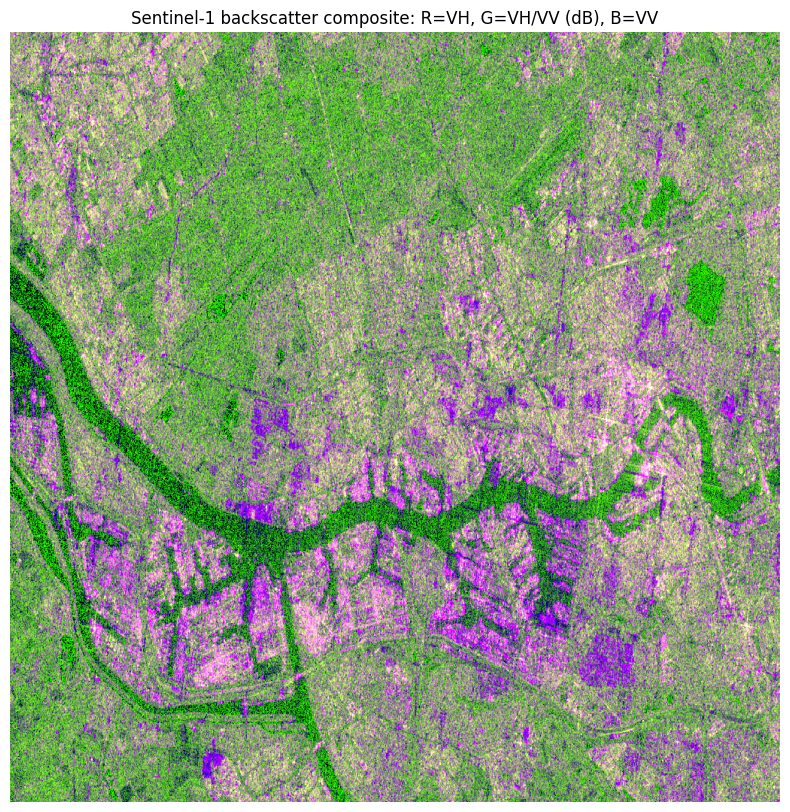

In [14]:
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Sentinel-1 backscatter composite: R=VH, G=VH/VV (dB), B=VV")
plt.axis("off")
plt.show()

## Interpreting the Composite

- **Water** (port basins, rivers): dark in both polarisations -- a smooth surface
  scatters the radar pulse away from the sensor rather than back to it -- reads as
  near-black.
- **Urban / industrial** (port structures, buildings, containers): bright in VV from
  double-bounce reflection off vertical structures -- reads bright blue/white.
- **Vegetation / farmland**: relatively brighter in VH, from volume scattering inside
  the canopy -- reads reddish/pink, the classic "vegetation red" of this composite.

If the scene instead looks uniformly noisy, inverted (water bright, urban dark), or
has a visible seam or gradient across the image, that is a real signal something in
the calibration path is wrong -- worth cross-checking against the reference numbers in
`scripts/sar_backscatter_prototype.py` (ADR S7.3) before trusting the pipeline further.

**Scope reminder:** this is Phase 1 -- ellipsoid geometry only, no terrain correction.
Expect visible brightness gradients with local incidence angle over hilly terrain;
that is expected, not a bug (see the ADR's scientific accuracy statement, S5).